In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
%matplotlib inline
pio.renderers.default = "plotly_mimetype+notebook_connected"

# Oracles Pt 1: Price Aggregation

Oracles provide off-chain asset prices to on-chain protocols. Given there are multiple exchanges that list assets at different prices, these prices are aggregated to arrive at a single price. We survey popular price aggregation methods in this notebook.

## Background

### Kimchi Premium
Token prices differ across markets. For example, BTC prices on US and KOR exchanges differed up to 15% during the 2018 crypto crash, known as the "kimchi premium".

In [2]:
for file in glob.glob("data/*.csv"):
    print(file)

data/2018-kor-upbit-btc-usd.csv
data/2018-uk-bitstamp-btc-usd.csv
data/2018-jp-bitflyer-btc-usd.csv
data/2018-us-gemini-btc-usd.csv


In [3]:
kimchi_dict = dict()
for file in glob.glob("data/*.csv"):
    key = file.split('-')[2]
    kimchi_dict[key] = pd.read_csv(file, parse_dates=['Date'])

In [4]:
for key in kimchi_dict.keys():
    print(key)
    print(kimchi_dict[key].columns.values)

upbit
['Date' 'Close' 'Open' 'High' 'Low' 'Volume BTC']
bitstamp
['Date' 'Close (8 PM EST)' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']
bitflyer
['Date' 'close' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']
gemini
['Date' 'Close (8 PM EST)' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']


In [5]:
for key in kimchi_dict.keys():
    kimchi_dict[key].columns.values[1] = 'Close'
    print(kimchi_dict[key].columns.values)

['Date' 'Close' 'Open' 'High' 'Low' 'Volume BTC']
['Date' 'Close' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']
['Date' 'Close' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']
['Date' 'Close' 'high' 'low' 'open' 'Volume BTC' 'Volume USD']


In [6]:
kimchi_df = kimchi_dict['upbit'][['Date','Close']].rename(columns={'Close':'upbit'}).set_index('Date', drop=True)
for key in list(kimchi_dict.keys())[-3:]:
    kimchi_df = pd.concat([kimchi_df, kimchi_dict[key][['Date','Close']].rename(columns={'Close':key}).set_index('Date', drop=True)], join='inner', axis=1)

kimchi_df = kimchi_df.rename(columns={'upbit':'KOR-upbit', 'bitstamp':'UK-bitstamp','bitflyer':'JP-bitflyer','gemini':'US-gemini'})

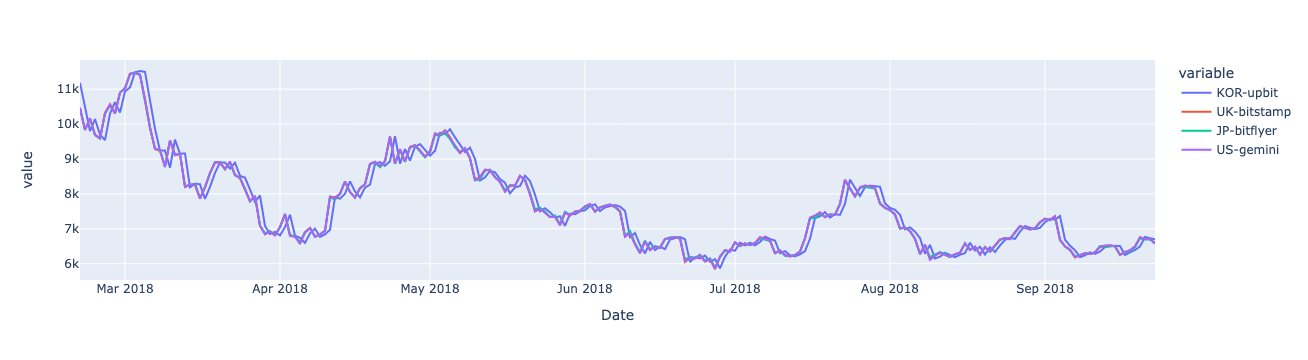

In [7]:
fig = px.line(kimchi_df, x=kimchi_df.index, y=list(kimchi_df.columns))
fig.update_traces(mode="lines", hovertemplate=None)
fig.update_layout(hovermode="x unified")
fig.show()

We see deviations most clearly from KOR and US exchanges in the hundreds of USDs. To further clarify this divergence, we plot the percent change of KOR, UK, and JP BTC prices against US prices.

In [8]:
from itertools import combinations
 
key_comb = combinations(list(kimchi_df.keys())[::-1], 2)
 
# Print the obtained combinations
for key_pair in list(key_comb):
    key1 = key_pair[0]
    key2 = key_pair[1]
    kimchi_df[f'{key1.split("-")[0]}-{key2.split("-")[0]}'] = (kimchi_df[key1] - kimchi_df[key2]) / kimchi_df[key1]

In [9]:
kimchi_df

,KOR-upbit,UK-bitstamp,JP-bitflyer,US-gemini,US-JP,US-UK,US-KOR,JP-UK,JP-KOR,UK-KOR
Date,,,,,,,,,,
2018-02-20,11182.0,10449.40,10446.40,10475.00,0.002730,0.002444,-0.067494,-0.000287,-0.070417,-0.070109
2018-02-21,10444.0,9843.34,9832.23,9829.96,-0.000231,-0.001361,-0.062466,-0.001130,-0.062221,-0.061022
2018-02-22,9800.0,10166.10,10153.90,10161.62,0.000760,-0.000441,0.035587,-0.001202,0.034854,0.036012
2018-02-23,10140.0,9689.99,9682.70,9697.21,0.001496,0.000745,-0.045662,-0.000753,-0.047229,-0.046441
2018-02-24,9699.5,9590.04,9580.60,9595.00,0.001501,0.000517,-0.010891,-0.000985,-0.012410,-0.011414
...,...,...,...,...,...,...,...,...,...,...
2018-09-19,6393.9,6492.98,6478.42,6495.87,0.002686,0.000445,0.015698,-0.002247,0.013046,0.015260
2018-09-20,6491.3,6749.45,6727.00,6759.51,0.004810,0.001488,0.039679,-0.003337,0.035038,0.038248
2018-09-21,6767.0,6710.01,6691.72,6710.26,0.002763,0.000037,-0.008456,-0.002733,-0.011250,-0.008493


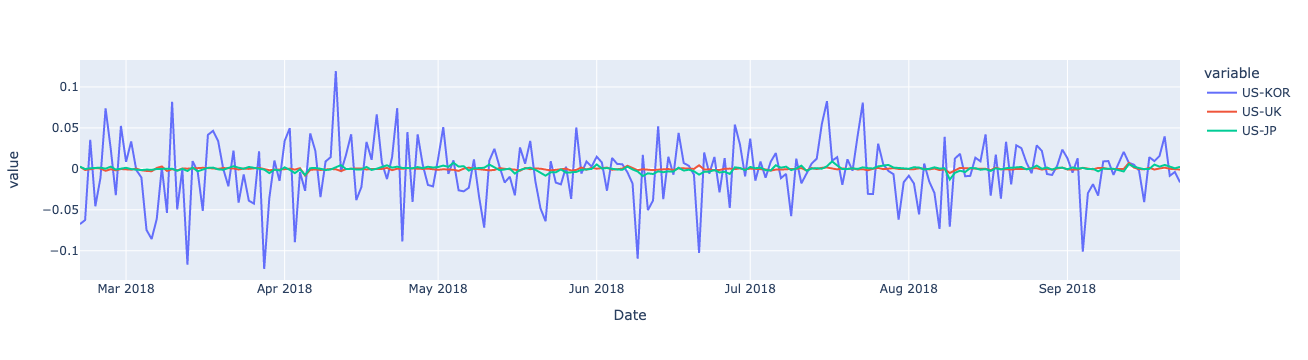

In [10]:
fig = px.line(kimchi_df, x=kimchi_df.index, y=list(kimchi_df.columns)[4:7][::-1])
fig.update_traces(mode="lines", hovertemplate=None)
fig.update_layout(hovermode="x unified")
fig.show()

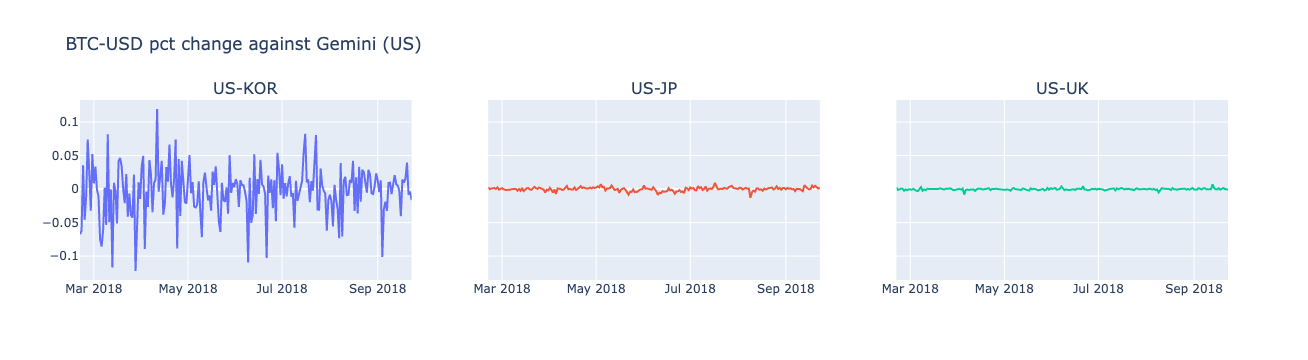

In [11]:
fig = make_subplots(
    rows=1, cols=3, 
    shared_yaxes=True,
    subplot_titles=("US-KOR","US-JP", "US-UK")
)
fig.add_trace(
    go.Scatter(x=kimchi_df.index, y=kimchi_df['US-KOR'],name='US-KOR'),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=kimchi_df.index, y=kimchi_df['US-JP'],name='US-JP'),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(x=kimchi_df.index, y=kimchi_df['US-UK'],name='US-UK'),
    row=1, col=3
)
fig.update_layout(title_text="BTC-USD pct change against Gemini (US)", showlegend=False)
fig.show()

In [12]:
kimchi_df.describe()

,KOR-upbit,UK-bitstamp,JP-bitflyer,US-gemini,US-JP,US-UK,US-KOR,JP-UK,JP-KOR,UK-KOR
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000
mean,7662.535185,7641.696435,7639.334444,7640.282083,0.000004,-0.000176,-0.003205,-0.000186,-0.003184,-0.003027
std,1298.327717,1274.390903,1267.967233,1273.425454,0.002815,0.001339,0.037384,0.002727,0.036583,0.037292
min,5867.100000,5848.330000,5885.800000,5850.130000,-0.013064,-0.008268,-0.122259,-0.008722,-0.121310,-0.121977
25%,6598.300000,6583.225000,6580.355000,6576.585000,-0.001112,-0.000781,-0.021609,-0.001802,-0.021714,-0.020943
50%,7400.900000,7375.305000,7389.215000,7383.215000,0.000247,-0.000133,0.000849,-0.000348,0.000931,-0.000960
75%,8435.250000,8422.040000,8408.852500,8414.807500,0.001541,0.000471,0.015063,0.001221,0.016718,0.015910
max,11520.000000,11463.270000,11481.000000,11467.190000,0.009140,0.007185,0.119488,0.011284,0.117838,0.119865


The Kimchi Premium (US-KOR) reaches a maximum of +/-12% with 3.7% volatility, a significantly divergence in price (and a theoretical arbitrage opportunity.)

### Lack of One Price Law
In TradFi, all equities have the same price under Reg NMS, colloquially known as Law of One Price. This regulation is not present for crypto assets as we see with Kimchi Premium as an extreme case. The lack of one price law for tokens gives rise to the question: what is the accurate price of a token?

This is a problem for both TradFi and DeFi. DeFi protocols rely on accurate pricing of assets on centralized exchanges:
- AMMs rely on arbitrageurs to converge to CEX prices
- DeFi lending protocols rely on CEXes to determine value of collateral
- Lending protocols also rely on CEXes to avoid on-chain oracle manipulation
- Tokenized funds rely on off-chain fund performance data

We survey the methods used by off-chain and on-chain providers, starting with off-chain data aggregators.

## Off-Chain Price Aggregators



| Provider      | Aggregation | Methodology                                              |
|---------------|-------------|----------------------------------------------------------|
| Coin Metrics  | Median      | Average of volume weight + inverse price variance weight |
| Coin Metrics  | None        | Select single market (Principal Market)                  |
| CoinGecko     | Mean        | Volume weighted average                                  |
| CoinMarketCap | Mean        | Volume weighted average                                  |